<h1 style="text-align: center;">Telco Customer Churn Analysis & Prediction</h1>

## Objective
The objective of this project is to identify customers who are likely to churn, enabling the business to take proactive retention actions and reduce revenue loss.

# 1. Importing Libraries

In this step, we import all necessary libraries for data analysis and modeling.

In [146]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc

<br><br>

# 2. Data Loading

In this step, we load the dataset and inspect the first few rows
to understand the structure of the data.

In [147]:
df = pd.read_excel("telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


<br><br>

# 3. Basic Data Understanding
The dataset was explored to understand its structure, data types, and check for missing values before further processing.

In [148]:
df.shape

(7043, 33)

In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [150]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [151]:
df.isnull().sum().to_frame(name = "Null Count")

,Null Count
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [152]:
df.duplicated().sum()

np.int64(0)

<br><br>

# 4. Data Cleaning & Preprocessing

Data cleaning steps were performed to ensure data quality, including:
- Handling missing values
- Removing duplicate records
- Standardizing categorical values

These steps ensure the dataset is consistent and ready for analysis.

# 4.1  Removing Irrelevant and Leakage Columns

The following columns were removed as part of preprocessing:

- **Identifier Columns**: 
  CustomerID was removed because it is a unique identifier and does not contribute to prediction.

- **Geographical Columns**: 
  Country, State, City, Zip Code, Latitude, Longitude were removed as they do not significantly impact churn behavior and may introduce noise.

- **Redundant Columns**: 
  Count column was removed as it has no meaningful information.

- **Data Leakage Columns**: 
  Churn Value, Churn Score, and CLTV were removed because they contain post-derived information that could lead to data leakage.

- **Post-outcome Column**: 
  Churn Reason was removed as it is only available after the customer has churned, making it unsuitable for prediction.

In [153]:
drop_cols = [
    'CustomerID', 'Count', 'Country', 'State', 'City',
    'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
    'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason'
]

df = df.drop(columns=drop_cols)

df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes


# 4.2  Fixing Data Types

The 'Total Charges' column is currently in object format. We convert it to numeric and handle any invalid values.

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [155]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [156]:
df.isnull().sum().to_frame(name = "Null Count")

,Null Count
Gender,0
Senior Citizen,0
Partner,0
Dependents,0
Tenure Months,0
Phone Service,0
Multiple Lines,0
Internet Service,0
Online Security,0
Online Backup,0


In [157]:
df[df["Total Charges"].isnull()]

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label
2234,Female,No,Yes,No,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
2438,Male,No,No,No,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
2568,Female,No,Yes,No,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
2667,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
2856,Female,No,Yes,No,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
4331,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
4687,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
5104,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5719,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6772,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


# 4.3  Handling Missing Values in Total Charges

Missing values in 'Total Charges' were observed only for customers with zero tenure. 
Since these customers are newly joined and have not incurred any charges yet, 
the missing values were replaced with 0 to reflect the business logic accurately.

In [158]:
df.loc[df['Total Charges'].isnull(), 'Total Charges'] = 0

In [159]:
df.isnull().sum().to_frame(name = "Null Count")

,Null Count
Gender,0
Senior Citizen,0
Partner,0
Dependents,0
Tenure Months,0
Phone Service,0
Multiple Lines,0
Internet Service,0
Online Security,0
Online Backup,0


# 4.4  Checking Duplicate Records

In this step, we check whether there are any duplicate rows 
in the dataset and remove them if present.

In [160]:
df.duplicated().sum()

np.int64(22)

# 4.5  Removing Duplicate Records

Duplicate rows were identified in the dataset. 
These were removed to ensure data quality and avoid bias in model training.

In [161]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [162]:
df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label'],
      dtype='object')

# 4.6 Standardizing Categorical Values

Certain columns contained values like 'No internet service' and 'No phone service', 
which were standardized to 'No' to reduce category complexity and ensure consistency 
for model training.

In [163]:
cols = [
    'Online Security','Online Backup','Device Protection',
    'Tech Support','Streaming TV','Streaming Movies'
]

for col in cols:
    df[col] = df[col].replace({'No internet service':'No'})

df['Multiple Lines'] = df['Multiple Lines'].replace({'No phone service':'No'})

In [164]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes


# 4.7  Standardizing Column Names

Column names were converted to lowercase and spaces were replaced with underscores 
to ensure consistency, improve readability, and make them easier to use in code.

In [165]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

<br><br>

#  5.  EDA  (Exploratory Data Analysis)

EDA was conducted to understand patterns and relationships between features 
and customer churn.

Visualizations were used to identify key factors influencing churn behavior.

# 5.1  Customer Churn Overview

This analysis aims to understand the distribution of customer churn  and identify the proportion of customers leaving the service.

In [166]:
df['churn_label'].value_counts()

churn_label
No     5164
Yes    1857
Name: count, dtype: int64

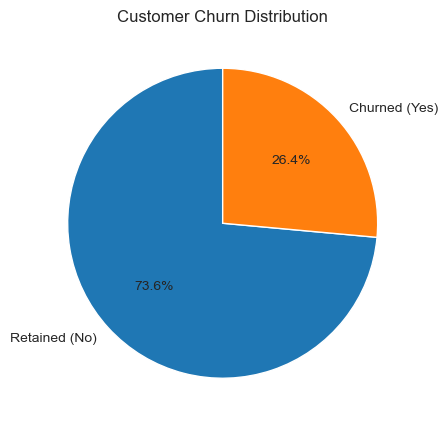

In [167]:
# Count values
churn_counts = df['churn_label'].value_counts()

# Pie chart
plt.figure(figsize=(5,8))
plt.pie(
    churn_counts,
    labels=['Retained (No)', 'Churned (Yes)'],
    autopct='%1.1f%%',
    startangle=90,
)
plt.title('Customer Churn Distribution')
plt.show()

# 5.2  Churn Analysis
A combined dashboard view is used to visualize multiple factors influencing churn, providing a quick overview of key patterns across customer segments.

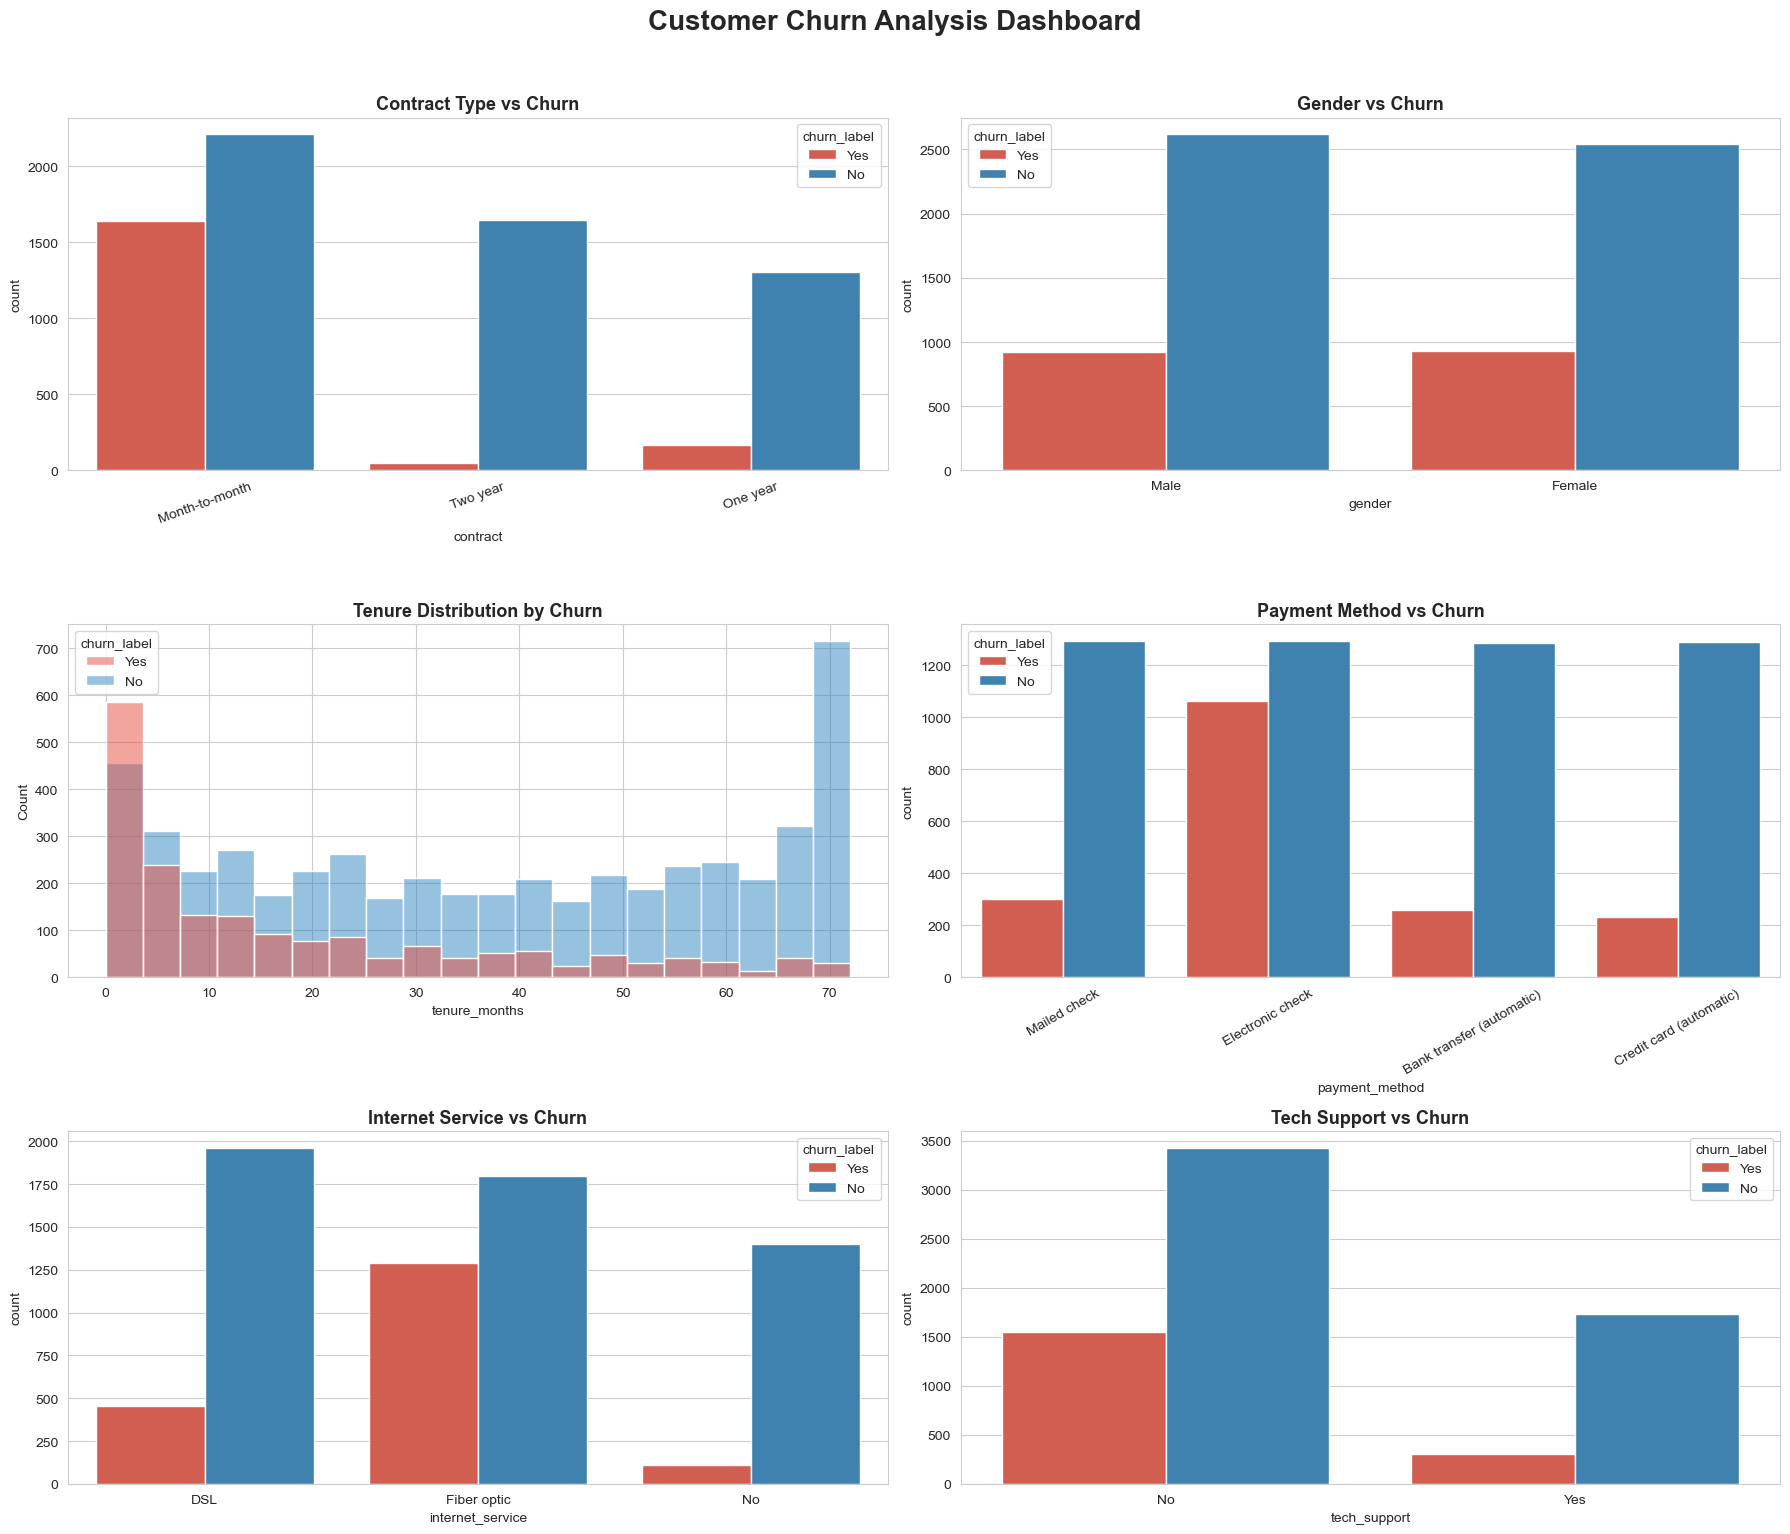

In [168]:
sns.set_style("whitegrid")

fig, ax = plt.subplots(3, 2, figsize=(18, 15))

palette_colors = {'No': '#2E86C1', 'Yes': '#E74C3C'}

plt.suptitle(
    "Customer Churn Analysis Dashboard",
    fontsize=20,
    fontweight='bold',
    y=1.02
)

# 1. Contract vs Churn
sns.countplot(x='contract', hue='churn_label', data=df, ax=ax[0][0], palette=palette_colors)
ax[0][0].set_title('Contract Type vs Churn', fontsize=13, fontweight='bold')
ax[0][0].tick_params(axis='x', rotation=20)

# 2. Gender vs Churn
sns.countplot(x='gender', hue='churn_label', data=df, ax=ax[0][1], palette=palette_colors)
ax[0][1].set_title('Gender vs Churn', fontsize=13, fontweight='bold')

# 3. Tenure vs Churn
sns.histplot(data=df, x='tenure_months', hue='churn_label', bins=20, ax=ax[1][0], palette=palette_colors)
ax[1][0].set_title('Tenure Distribution by Churn', fontsize=13, fontweight='bold')

# 4. Payment Method vs Churn
sns.countplot(x='payment_method', hue='churn_label', data=df, ax=ax[1][1], palette=palette_colors)
ax[1][1].set_title('Payment Method vs Churn', fontsize=13, fontweight='bold')
ax[1][1].tick_params(axis='x', rotation=30)

# 5. Internet Service vs Churn
sns.countplot(x='internet_service', hue='churn_label', data=df, ax=ax[2][0], palette=palette_colors)
ax[2][0].set_title('Internet Service vs Churn', fontsize=13, fontweight='bold')

# 6. Tech Support vs Churn
sns.countplot(x='tech_support', hue='churn_label', data=df, ax=ax[2][1], palette=palette_colors)
ax[2][1].set_title('Tech Support vs Churn', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# 5.2.1  Key Insights

- Month-to-month contracts show the highest churn compared to long-term plans.

- Customers with lower tenure are more likely to churn in the early stages.

- Higher monthly charges are associated with increased churn.

- Payment method influences churn, with electronic check users showing higher churn.

- Fiber optic users show relatively higher churn compared to other services.

- Customers without tech support are more likely to churn.

# 5.2.2  Business Recommendations

- Encourage customers to move to long-term contracts through targeted offers.

- Improve onboarding and early engagement to retain new customers.

- Review pricing strategy and offer flexible plans.

- Promote automatic payment methods for better retention.

- Improve service quality and support for fiber optic users.

- Strengthen tech support services to reduce churn.

# 5.3  Outlier Analysis

Outliers in numerical features were analyzed to ensure there are no extreme 
values that could negatively impact model performance.

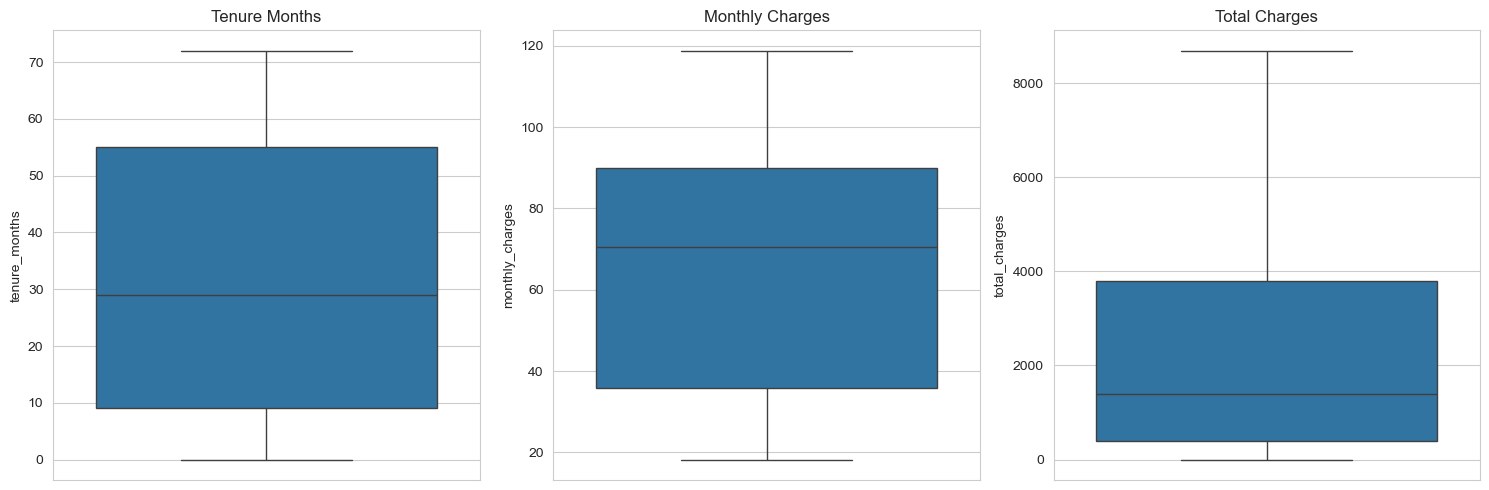

In [169]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y=df['tenure_months'])
plt.title('Tenure Months')

plt.subplot(1,3,2)
sns.boxplot(y=df['monthly_charges'])
plt.title('Monthly Charges')

plt.subplot(1,3,3)
sns.boxplot(y=df['total_charges'])
plt.title('Total Charges')

plt.tight_layout()
plt.show()

# 5.3.1  Outlier Analysis Insights

- All numerical features (tenure, monthly charges, total charges) fall within expected business ranges.

- No extreme or unrealistic outliers are observed in the dataset.

- Variations in charges reflect normal differences in customer plans and usage patterns.

- Higher total charges are associated with longer tenure customers, which is expected behavior.

<br><br>

# 6. Feature Engineering

New features were created to enhance model performance:

- Total Services: Number of services used by each customer
- Average Charges: Average spending behavior
- Tenure Group: Customer lifecycle segmentation

These features help capture customer engagement and behavior more effectively.

# 6.1  Total Services

A new feature was created to capture customer engagement by counting 
the number of services used by each customer.

In [170]:
df['total_services'] = df[[
    'online_security','online_backup','device_protection',
    'tech_support','streaming_tv','streaming_movies'
]].apply(lambda x: (x == 'Yes').sum(), axis=1)

# 6.2  Tenure Group

Customers were grouped based on their tenure to represent different 
stages of the customer lifecycle.

In [171]:
df['tenure_group'] = pd.cut(
    df['tenure_months'],
    bins=[0,12,36,72],
    labels=['New','Mid','Loyal']
)

# 6.3  Average Charges

A feature was created to represent the average monthly spending 
of customers over their tenure.

In [172]:
df['avg_charges'] = df['total_charges'] / (df['tenure_months'] + 1)

In [173]:
df.head()

,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,...,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,total_services,tenure_group,avg_charges
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,2,New,36.050000
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0,New,50.550000
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,3,New,91.166667
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,4,Mid,105.036207
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,4,Loyal,100.726000


<br><br>

# 7.  Data Preparation

Categorical variables were encoded into numerical format, and the dataset was split into training and testing sets.This ensures the model can generalize well to unseen data.

# 7.1  Encoding Target Variable

The target variable was converted into numerical format 
to prepare it for machine learning models.

In [174]:
df['churn_label'] = df['churn_label'].map({'No': 0, 'Yes': 1})

In [175]:
df['churn_label'].value_counts()

churn_label
0    5164
1    1857
Name: count, dtype: int64

# 7.2  Encoding Categorical Features

Categorical variables were converted into numerical format using one-hot encoding 
to make them suitable for machine learning models.

In [176]:
df = pd.get_dummies(df, drop_first=True)

In [177]:
df.head()

,tenure_months,monthly_charges,total_charges,churn_label,total_services,avg_charges,gender_Male,senior_citizen_Yes,partner_Yes,dependents_Yes,...,streaming_tv_Yes,streaming_movies_Yes,contract_One year,contract_Two year,paperless_billing_Yes,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check,tenure_group_Mid,tenure_group_Loyal
0,2,53.85,108.15,1,2,36.050000,True,False,False,False,...,False,False,False,False,True,False,False,True,False,False
1,2,70.70,151.65,1,0,50.550000,False,False,False,True,...,False,False,False,False,True,False,True,False,False,False
2,8,99.65,820.50,1,3,91.166667,False,False,False,True,...,True,True,False,False,True,False,True,False,False,False
3,28,104.80,3046.05,1,4,105.036207,False,False,True,True,...,True,True,False,False,True,False,True,False,True,False
4,49,103.70,5036.30,1,4,100.726000,True,False,False,True,...,True,True,False,False,True,False,False,False,False,True


# 7.3  Converting Boolean Features

Boolean values were converted into numerical format (0 and 1) 
to ensure compatibility with machine learning algorithms.

In [178]:
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   tenure_months                           7021 non-null   int64  
 1   monthly_charges                         7021 non-null   float64
 2   total_charges                           7021 non-null   float64
 3   churn_label                             7021 non-null   int64  
 4   total_services                          7021 non-null   int64  
 5   avg_charges                             7021 non-null   float64
 6   gender_Male                             7021 non-null   int64  
 7   senior_citizen_Yes                      7021 non-null   int64  
 8   partner_Yes                             7021 non-null   int64  
 9   dependents_Yes                          7021 non-null   int64  
 10  phone_service_Yes                       7021 non-null   int64  
 

In [180]:
df.head()

,tenure_months,monthly_charges,total_charges,churn_label,total_services,avg_charges,gender_Male,senior_citizen_Yes,partner_Yes,dependents_Yes,...,streaming_tv_Yes,streaming_movies_Yes,contract_One year,contract_Two year,paperless_billing_Yes,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check,tenure_group_Mid,tenure_group_Loyal
0,2,53.85,108.15,1,2,36.050000,1,0,0,0,...,0,0,0,0,1,0,0,1,0,0
1,2,70.70,151.65,1,0,50.550000,0,0,0,1,...,0,0,0,0,1,0,1,0,0,0
2,8,99.65,820.50,1,3,91.166667,0,0,0,1,...,1,1,0,0,1,0,1,0,0,0
3,28,104.80,3046.05,1,4,105.036207,0,0,1,1,...,1,1,0,0,1,0,1,0,1,0
4,49,103.70,5036.30,1,4,100.726000,1,0,0,1,...,1,1,0,0,1,0,0,0,0,1


# 7.4  Train-Test Split

The dataset was split into training and testing sets 
to evaluate model performance on unseen data.

In [181]:
X = df.drop('churn_label', axis=1)
y = df['churn_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7.5  Feature Scaling

Numerical features were standardized using training data 
to avoid data leakage and ensure fair model evaluation.

In [182]:
scaler = StandardScaler()

num_cols = ['tenure_months', 'monthly_charges', 'total_charges', 'avg_charges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

<br><br>

# 8.  Model Building

A baseline model using Logistic Regression was developed to establish initial performance.

An advanced model using LightGBM was then implemented to improve prediction accuracy and capture complex patterns.

# 8.1  Baseline Model: Logistic Regression

Logistic Regression was used as a baseline model to establish 
a reference performance for churn prediction.

In [183]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# 8.1.1  Evaluation: Logistic Regression

The baseline model was evaluated to understand its performance 
in predicting churn and to serve as a benchmark for improvement.

In [184]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8135231316725978
[[930  78]
 [184 213]]
              precision    recall  f1-score   support

           0       0.83      0.92      0.88      1008
           1       0.73      0.54      0.62       397

    accuracy                           0.81      1405
   macro avg       0.78      0.73      0.75      1405
weighted avg       0.81      0.81      0.80      1405



# 8.2  Advanced Model: LightGBM

LightGBM was used as the primary model due to its ability 
to capture complex patterns and improve prediction performance.

In [185]:
lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    verbose=-1 
)

lgbm.fit(X_train, y_train)

LGBMClassifier(class_weight='balanced', learning_rate=0.05, max_depth=6,
               n_estimators=200, random_state=42, verbose=-1)

# 8.2.1  Prediction

Predictions were generated using the trained LightGBM model 
to evaluate its performance on unseen data.

In [186]:
y_prob = lgbm.predict_proba(X_test)[:,1]

# Threshold tuning for better recall
y_pred_lgbm = (y_prob > 0.4).astype(int)

# 8.2.2  Evaluation: LightGBM

The LightGBM model was evaluated using accuracy, confusion matrix, 
and classification metrics to assess its effectiveness.

In [187]:
print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print(confusion_matrix(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))

LightGBM Accuracy: 0.7587188612099645
[[743 265]
 [ 74 323]]
              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1008
           1       0.55      0.81      0.66       397

    accuracy                           0.76      1405
   macro avg       0.73      0.78      0.74      1405
weighted avg       0.81      0.76      0.77      1405



<br><br>

# 9.  Model Comparison

The performance of Logistic Regression and LightGBM was compared 
to identify the most effective model for churn prediction.

In [188]:
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("LightGBM:", accuracy_score(y_test, y_pred_lgbm))

Logistic Regression: 0.8135231316725978
LightGBM: 0.7587188612099645


# 9.1  Model Comparison and Final Selection

Logistic Regression achieved higher accuracy, but failed to identify 
a large number of churn customers.

LightGBM, on the other hand, provided significantly better recall 
for churn prediction, successfully identifying most high-risk customers.

Since the business objective is to reduce customer churn, 
LightGBM was selected as the final model.

<br><br>

# 10.  Hyperparameter Tuning

Multiple parameter combinations were tested, including tree depth, learning rate, and sampling strategies, to identify the optimal LightGBM configuration.

In [189]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Base model
lgbm = LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

# Parameter grid
param_grid = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.03],
    'max_depth': [6, 8],
    'num_leaves': [31, 40],
    'min_child_samples': [20],
    'subsample': [0.8]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring='recall',   # churn class recall important
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Fit
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best CV Recall:", grid_search.best_score_)

# Best model
best_lgbm = grid_search.best_estimator_

# Probability prediction
y_prob = best_lgbm.predict_proba(X_test)[:, 1]

# Threshold tuning
y_pred = (y_prob > 0.40).astype(int)

# Evaluation
print("\nTuned LightGBM Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters: {'learning_rate': 0.03, 'max_depth': 6, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 40, 'subsample': 0.8}
Best CV Recall: 0.7760116950169426

Tuned LightGBM Accuracy: 0.7629893238434163

Confusion Matrix:
 [[733 275]
 [ 58 339]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.73      0.81      1008
           1       0.55      0.85      0.67       397

    accuracy                           0.76      1405
   macro avg       0.74      0.79      0.74      1405
weighted avg       0.82      0.76      0.77      1405



# 10.1  ROC Curve and AUC Score

- The ROC (Receiver Operating Characteristic) curve was used to evaluate 
the model's ability to distinguish between churn and non-churn customers.

- The AUC (Area Under Curve) score provides a measure of how well the model 
can separate the two classes.

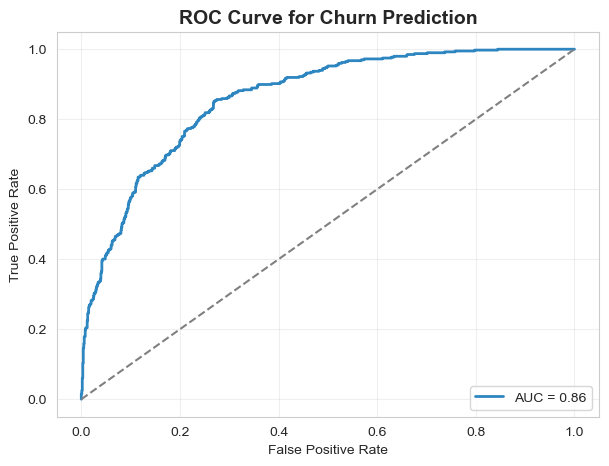

In [190]:
# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, color='#2E86C1', linewidth=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--', color='gray')

plt.title('ROC Curve for Churn Prediction', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')

plt.grid(alpha=0.3)
plt.show()

# 10.1.1   ROC Curve Analysis

The model shows strong performance with an AUC of 0.86, indicating good ability to distinguish between churn and non-churn customers.

<br><br>

# 11.   Conclusion

- This project successfully analyzes customer behavior and builds a machine learning model to predict churn. 

- With strong recall and an AUC score of 0.86, the model effectively identifies high-risk customers, helping businesses take proactive actions to improve customer retention.

<br><br><br>